# LAB | Ensemble Methods

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In this Lab, you should try different ensemble methods in order to see if can obtain a better model than before. In order to do a fair comparison, you should perform the same feature scaling, engineering applied in previous Lab.

In [1]:
#Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import accuracy_score, classification_report

In [2]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
spaceship = spaceship.dropna()

In [4]:
spaceship.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

Now perform the same as before:
- Feature Scaling
- Feature Selection


In [5]:
X = spaceship.select_dtypes(include="number")
y = spaceship["Transported"]

**Perform Train Test Split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Selection** - now you will try to apply different ensemble methods in order to get a better model

- Bagging and Pasting

In [8]:
bagging = BaggingClassifier(random_state=42)
bagging.fit(X_train_scaled, y_train)
pred_bag = bagging.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_bag))
print(classification_report(y_test, pred_bag))

Accuracy: 0.7874432677760969
              precision    recall  f1-score   support

       False       0.81      0.74      0.78       653
        True       0.77      0.83      0.80       669

    accuracy                           0.79      1322
   macro avg       0.79      0.79      0.79      1322
weighted avg       0.79      0.79      0.79      1322



- Random Forests

In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.7950075642965204
              precision    recall  f1-score   support

       False       0.83      0.74      0.78       653
        True       0.77      0.85      0.81       669

    accuracy                           0.80      1322
   macro avg       0.80      0.79      0.79      1322
weighted avg       0.80      0.80      0.79      1322



- Gradient Boosting

In [10]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)
pred_gb = gb.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_gb))
print(classification_report(y_test, pred_gb))

Accuracy: 0.7957639939485628
              precision    recall  f1-score   support

       False       0.83      0.73      0.78       653
        True       0.77      0.86      0.81       669

    accuracy                           0.80      1322
   macro avg       0.80      0.80      0.79      1322
weighted avg       0.80      0.80      0.79      1322



- Adaptive Boosting

In [11]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_scaled, y_train)
pred_ada = ada.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_ada))
print(classification_report(y_test, pred_ada))

Accuracy: 0.7844175491679274
              precision    recall  f1-score   support

       False       0.81      0.74      0.77       653
        True       0.76      0.83      0.80       669

    accuracy                           0.78      1322
   macro avg       0.79      0.78      0.78      1322
weighted avg       0.79      0.78      0.78      1322



Which model is the best and why?

In [12]:
results = pd.DataFrame({
    "Model": [
        "Bagging",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_bag),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb),
        accuracy_score(y_test, pred_ada)]})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Gradient Boosting,0.795764
1,Random Forest,0.795008
0,Bagging,0.787443
3,AdaBoost,0.784418


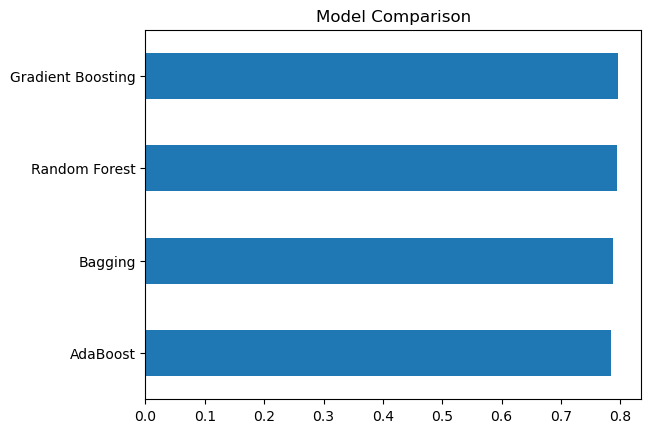

In [13]:
import matplotlib.pyplot as plt
results.sort_values("Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False)
plt.title("Model Comparison")
plt.ylabel("")
plt.show()

In [14]:
print(results.sort_values("Accuracy", ascending=False))

               Model  Accuracy
2  Gradient Boosting  0.795764
1      Random Forest  0.795008
0            Bagging  0.787443
3           AdaBoost  0.784418


Among the four ensemble methods tested, Gradient Boosting achieved the highest accuracy (approximately 80%) and was therefore selected as the best model. Its sequential learning approach allows it to correct previous prediction errors, resulting in better overall performance than Bagging, Random Forest, and AdaBoost on this dataset.